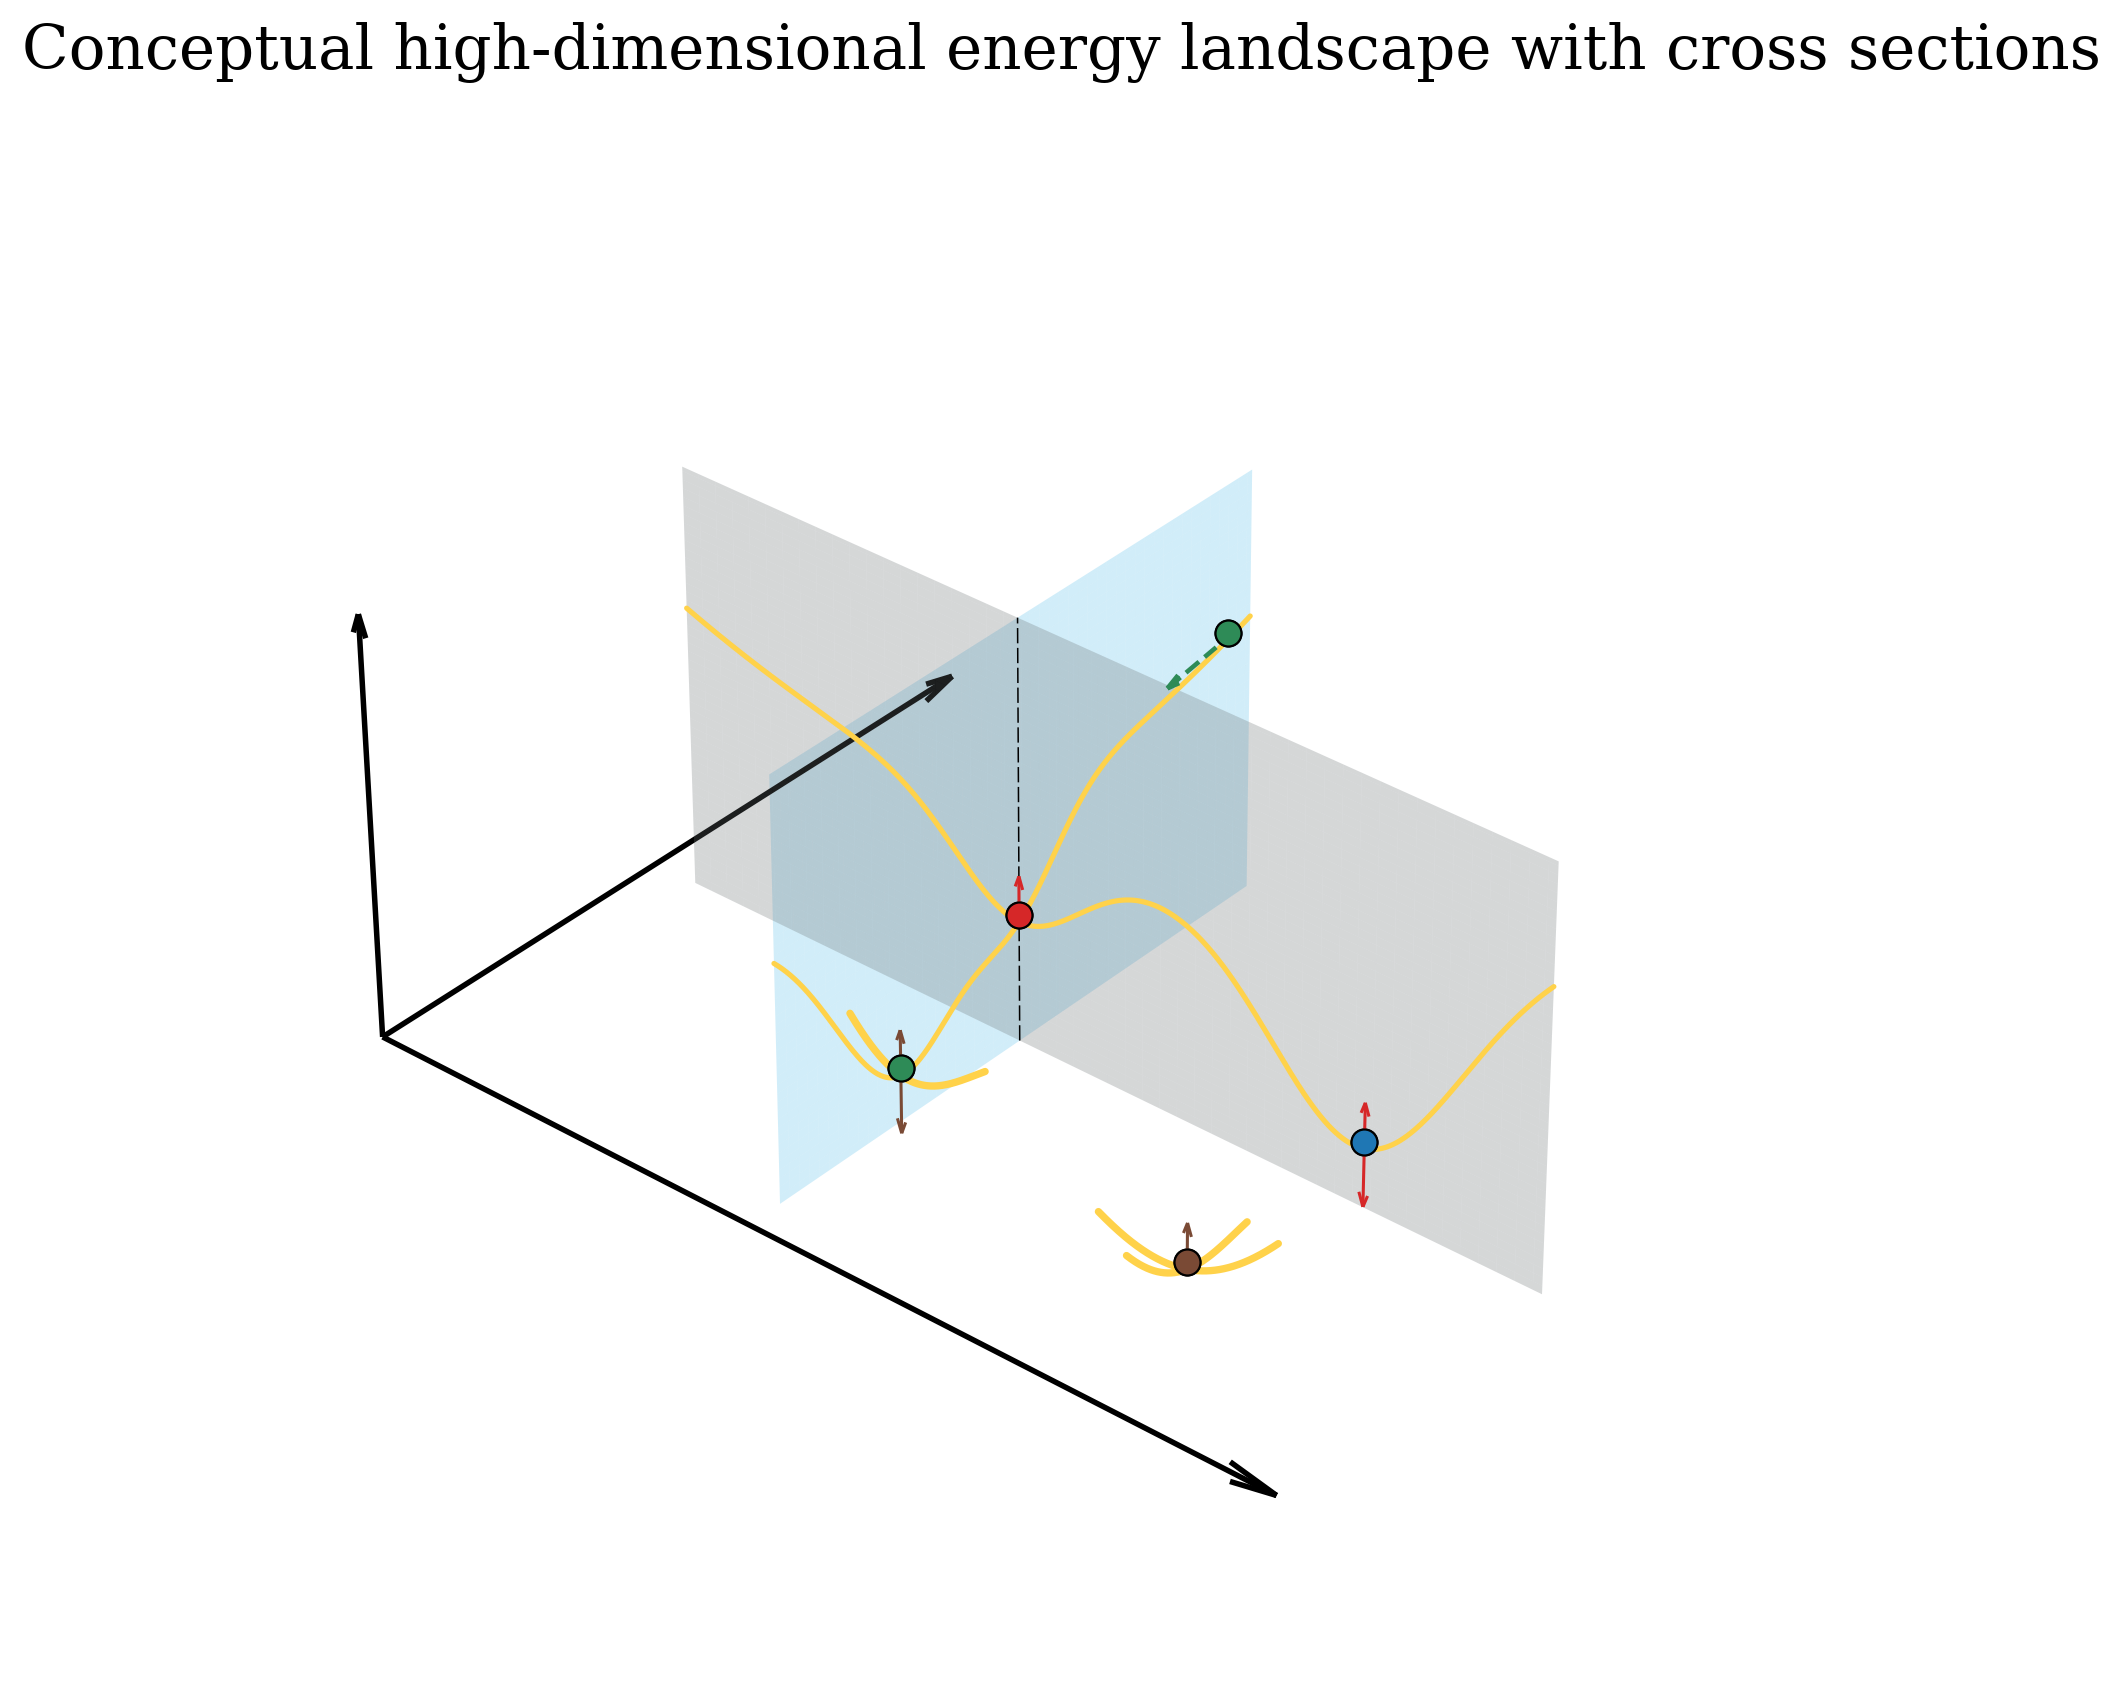

In [264]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# --------------------------------
# Style: similar to previous plot
# --------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "figure.dpi": 220,
    "savefig.dpi": 600,
    "axes.linewidth": 1.2,
    "font.size": 18,
})

# --------------------------------
# Grid for conceptual landscape
# --------------------------------
xmin, xmax = -2.0, 3.0
ymin, ymax = -2.0, 2.0

x = np.linspace(xmin, xmax, 340)
y = np.linspace(ymin, ymax, 300)
X, Y = np.meshgrid(x, y)

# --------------------------------
# Define four minima
# --------------------------------
shared_min = (0.0, 0.0)
unique_A = (0.0, -1.0)     # on plane x = 0
unique_B = (2.0, 0.0)      # on plane y = 0
off_plane = (2.0, -1.5)    # outside both cross sections
initial = (0.0, 1.8)

wells = [
    (*shared_min, 0.55, 0.35),
    (*unique_A,   1.25, 0.50),
    (*unique_B,   1.25, 0.50),
    (*off_plane,  1.65, 0.85),
]

# --------------------------------
# Energy landscape function
# --------------------------------
def raw_energy(x, y):
    z = 0.10 * (x**2 + 0.85 * y**2) + 0.015 * x * y

    for cx, cy, amp, sig in wells:
        z -= amp * np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * sig**2))

    # weak large-scale roughness for schematic morphology
    z += 0.05 * np.sin(1.3 * x) * np.cos(1.1 * y)

    return z

Zraw = raw_energy(X, Y)

shift = 0.0
Z = Zraw + shift

def energy(x, y):
    return raw_energy(x, y) + shift

# --------------------------------
# Figure
# --------------------------------
fig = plt.figure(figsize=(12.0, 8.0))
ax = fig.add_subplot(111, projection="3d", computed_zorder=False)

zmin = Z.min()
zmax = Z.max()
zrange = zmax - zmin
zbase = zmin - 0.12 * zrange

# --------------------------------
# Mask part of main energy landscape
# --------------------------------
Zplot = Z.copy()
row_indices, col_indices = np.indices(Zplot.shape)
mask = (-0.5 * row_indices + col_indices) > 280
Zplot[mask] = np.nan

# --------------------------------
# Main energy landscape
# --------------------------------
ax.plot_surface(
    X, Y, Zplot,
    rstride=8,
    cstride=8,
    color="#E8A34B",
    edgecolor="#6A4720",
    linewidth=0.00,
    antialiased=True,
    shade=False,
    alpha=0.00,
    zorder=1,
)

# --------------------------------
# Two perpendicular cross-section planes
# plane 1: x = 0
# plane 2: y = 0
# --------------------------------
plane_alpha = 0.28

# Plane x = 0
Yp, Zp = np.meshgrid(
    np.linspace(ymin, ymax, 100),
    np.linspace(zbase, zmax, 100)
)
Xp = np.zeros_like(Yp)

ax.plot_surface(
    Xp, Yp, Zp,
    color="#5BC0EB",
    alpha=plane_alpha,
    shade=False,
    linewidth=0,
    zorder=2,
)

# Plane y = 0
Xp2, Zp2 = np.meshgrid(
    np.linspace(xmin, xmax, 100),
    np.linspace(zbase, zmax, 100)
)
Yp2 = np.zeros_like(Xp2)

ax.plot_surface(
    Xp2, Yp2, Zp2,
    color="#697072",
    alpha=plane_alpha,
    shade=False,
    linewidth=0,
    zorder=3,
)

# --------------------------------
# Crossline of the two planes
# --------------------------------
zline = np.linspace(zbase, zmax, 300)

ax.plot(
    np.zeros_like(zline),
    np.zeros_like(zline),
    zline,
    color="black",
    lw=0.5,
    linestyle="--",
    dashes=(10, 3),
    zorder=20,
)

# --------------------------------
# Draw cross-section curves on the two main planes
# --------------------------------
yy = np.linspace(ymin, ymax, 500)
zz_xplane = energy(0.0, yy)

ax.plot(
    np.zeros_like(yy),
    yy,
    zz_xplane,
    color="#FFD24A",
    lw=1.7,
    solid_capstyle="round",
    zorder=30,
)

xx = np.linspace(xmin, xmax, 500)
zz_yplane = energy(xx, 0.0)

ax.plot(
    xx,
    np.zeros_like(xx),
    zz_yplane,
    color="#FFD24A",
    lw=1.7,
    solid_capstyle="round",
    zorder=31,
)

# --------------------------------
# Local energy lines around unique A minimum
# These are short local cuts along x and y directions.
# --------------------------------
off_x, off_y = unique_A

local_dx = 0.50
local_dy = 0.50

x_local = np.linspace(
    max(xmin, off_x - 0.3),
    min(xmax, off_x + local_dx),
    250
)
y_local_fixed = np.full_like(x_local, off_y)
z_local_x = energy(x_local, y_local_fixed)

ax.plot(
    x_local,
    y_local_fixed,
    z_local_x + 0.00,
    color="#FFD24A",
    lw=2.4,
    solid_capstyle="round",
    zorder=45,
)

'''y_local = np.linspace(
    max(ymin, off_y - local_dy),
    min(ymax, off_y + local_dy),
    250
)
x_local_fixed = np.full_like(y_local, off_x)
z_local_y = energy(x_local_fixed, y_local)

ax.plot(
    x_local_fixed,
    y_local,
    z_local_y + 0.00,
    color="#FFD24A",
    lw=2.4,
    solid_capstyle="round",
    zorder=46,
)'''

# --------------------------------
# Local energy lines around off-plane minimum
# These are short local cuts along x and y directions.
# --------------------------------
off_x, off_y = off_plane

local_dx = 0.50
local_dy = 0.50

x_local = np.linspace(
    max(xmin, off_x - local_dx),
    min(xmax, off_x + local_dx),
    250
)
y_local_fixed = np.full_like(x_local, off_y)
z_local_x = energy(x_local, y_local_fixed)

ax.plot(
    x_local,
    y_local_fixed,
    z_local_x + 0.00,
    color="#FFD24A",
    lw=2.4,
    solid_capstyle="round",
    zorder=45,
)

y_local = np.linspace(
    max(ymin, off_y - local_dy),
    min(ymax, off_y + local_dy),
    250
)
x_local_fixed = np.full_like(y_local, off_x)
z_local_y = energy(x_local_fixed, y_local)

ax.plot(
    x_local_fixed,
    y_local,
    z_local_y + 0.00,
    color="#FFD24A",
    lw=2.4,
    solid_capstyle="round",
    zorder=46,
)

# Optional small vertical guide through off-plane minimum
'''z_off = energy(off_x, off_y)
ax.plot(
    [off_x, off_x],
    [off_y, off_y],
    [zbase, z_off],
    color="#8E44AD",
    lw=0.8,
    linestyle="--",
    dashes=(8, 4),
    zorder=25,
)'''

# --------------------------------
# Mark minima
# --------------------------------
minima = [
    (shared_min[0], shared_min[1], "shared", "#D62728"),
    (unique_A[0], unique_A[1], "unique on plane 1", "#2E8B57"),
    (unique_B[0], unique_B[1], "unique on plane 2", "#1F77B4"),
    (off_plane[0], off_plane[1], "off-plane", "#7A4A35"),
    (initial[0], initial[1], "initial", "#2E8B57"),
]

for mx, my, label, color in minima:
    mz = energy(mx, my) + 0.05

    ax.scatter(
        [mx], [my], [mz],
        s=72,
        color=color,
        edgecolor="black",
        linewidth=0.7,
        depthshade=False,
        zorder=60,
    )

# --------------------------------
# Arrows showing perturbation / dynamics
# --------------------------------
arrow_len = 0.38

# shared minimum perturbation
mx, my = shared_min
mz = energy(mx, my) + 0.05
ax.quiver(
    mx, my, mz + 0.08,
    0, 0, arrow_len/2,
    color="#D62728",
    linewidth=1.0,
    arrow_length_ratio=0.45,
    zorder=70,
)

# unique A perturbation
mx, my = unique_A
mz = energy(mx, my) + 0.05
ax.quiver(
    mx, my, mz + 0.08,
    0, 0, arrow_len/2,
    color="#7A4A35",
    linewidth=1.0,
    arrow_length_ratio=0.45,
    zorder=71,
)
ax.quiver(
    mx, my, mz - 0.08,
    0, 0, -arrow_len,
    color="#7A4A35",
    linewidth=1.0,
    arrow_length_ratio=0.25,
    zorder=72,
)

# unique B perturbation
mx, my = unique_B
mz = energy(mx, my) + 0.05
ax.quiver(
    mx, my, mz + 0.08,
    0, 0, arrow_len/2,
    color="#D62728",
    linewidth=1.0,
    arrow_length_ratio=0.45,
    zorder=73,
)
ax.quiver(
    mx, my, mz - 0.08,
    0, 0, -arrow_len,
    color="#D62728",
    linewidth=1.0,
    arrow_length_ratio=0.25,
    zorder=74,
)

# off-plane perturbation
mx, my = off_plane
mz = energy(mx, my) + 0.05
ax.quiver(
    mx, my, mz + 0.08,
    0, 0, arrow_len/2,
    color="#7A4A35",
    linewidth=1.0,
    arrow_length_ratio=0.45,
    zorder=75,
)

# initial dynamics
mx, my = initial
mz = energy(mx, my)
ax.quiver(
    mx, my - 0.1, mz,
    0.05, -0.5, 0,
    color="#2E8B57",
    linewidth=1.5,
    linestyle="--",
    arrow_length_ratio=0.25,
    zorder=76,
)

# Replot points on top
for i, (mx, my, label, color) in enumerate(minima, start=80):
    mz = energy(mx, my) + 0.05

    ax.scatter(
        [mx], [my], [mz],
        s=72,
        color=color,
        edgecolor="black",
        linewidth=0.7,
        depthshade=False,
        zorder=i,
    )

# --------------------------------
# Custom minimal coordinate axes
# --------------------------------
ax.set_xlim(xmin - 0.35, xmax + 0.20)
ax.set_ylim(ymin - 0.35, ymax + 0.20)
ax.set_zlim(zbase, zmax)

x0 = xmin #- 0.25
y0 = ymin #- 0.25

'''# x coordinate line
ax.plot(
    [x0, xmax],
    [y0, y0],
    [zbase, zbase],
    color="black",
    lw=1.8,
    zorder=100,
)

# y coordinate line
ax.plot(
    [x0, x0],
    [y0, ymax],
    [zbase, zbase],
    color="black",
    lw=1.8,
    zorder=101,
)

# energy coordinate line
ax.plot(
    [x0, x0],
    [y0, y0],
    [zbase, zmax],
    color="black",
    lw=1.8,
    zorder=102,
)'''
# --------------------------------
# Custom minimal coordinate axes with arrows
# --------------------------------
ax.set_xlim(xmin - 0.35, xmax + 0.20)
ax.set_ylim(ymin - 0.35, ymax + 0.20)
ax.set_zlim(zbase, zmax)

x0 = xmin - 0.25
y0 = ymin - 0.25

arrow_lw = 1.8
arrow_ratio = 0.05

# x coordinate arrow
ax.quiver(
    x0, y0, zbase,          # starting point
    xmax - x0, 0, 0,        # direction vector
    color="black",
    linewidth=arrow_lw,
    arrow_length_ratio=arrow_ratio,
    normalize=False,
)

# y coordinate arrow
ax.quiver(
    x0, y0, zbase,
    0, ymax - y0 + 0.6, 0,
    color="black",
    linewidth=arrow_lw,
    arrow_length_ratio=arrow_ratio,
    normalize=False,
)

# z / energy coordinate arrow
ax.quiver(
    x0, y0, zbase,
    0, 0, zmax - zbase,
    color="black",
    linewidth=arrow_lw,
    arrow_length_ratio=arrow_ratio,
    normalize=False,
)

# --------------------------------
# Hide default axes
# --------------------------------
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_zlabel("")
ax.set_title(
    "Conceptual high-dimensional energy landscape with cross sections",
    pad=18,
    fontsize=20,
)

# Clean panes and default lines
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(False)

try:
    ax.xaxis.line.set_linewidth(0)
    ax.yaxis.line.set_linewidth(0)
    ax.zaxis.line.set_linewidth(0)
except Exception:
    pass

# --------------------------------
# View / aspect
# --------------------------------
ax.view_init(elev=34, azim=-50)

try:
    ax.set_box_aspect((1.75, 1.18, 0.72))
except Exception:
    pass

# --------------------------------
# Turn off 3D box edges / panes
# --------------------------------
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.xaxis.pane.set_edgecolor((1, 1, 1, 0))
ax.yaxis.pane.set_edgecolor((1, 1, 1, 0))
ax.zaxis.pane.set_edgecolor((1, 1, 1, 0))

ax.grid(False)

# Hide default 3D axis box lines
try:
    ax.xaxis.line.set_color((1, 1, 1, 0))
    ax.yaxis.line.set_color((1, 1, 1, 0))
    ax.zaxis.line.set_color((1, 1, 1, 0))

    ax.xaxis.line.set_linewidth(0)
    ax.yaxis.line.set_linewidth(0)
    ax.zaxis.line.set_linewidth(0)
except Exception:
    pass

plt.tight_layout()
plt.show()